# Assignment 12: Neural Network and Deep Learning Basics
### Image Classification on Fashion-MNIST with a Feedforward Neural Network

**Author:** Jean Billa
**Dataset:** [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) (70,000 grayscale 28x28 images, 10 clothing categories)

This notebook builds, trains, and evaluates a feedforward neural network for image
classification, and compares it against the expectations of traditional machine
learning to illustrate the practical benefits of deep learning.


## 1. Introduction

Fashion-MNIST is a drop-in replacement for the classic MNIST digit dataset. It
contains 70,000 28x28 grayscale images of clothing items split across 10 classes
(T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle
boot). It is harder than MNIST digits because clothing silhouettes overlap much
more (e.g. Shirt vs. T-shirt vs. Coat vs. Pullover), which makes it a good
dataset for showing where a simple feedforward network struggles compared to
more specialized architectures such as CNNs, while still being small enough to
train quickly.

**Model architecture (high level):** the images are flattened into 784-length
vectors and passed through one or more fully-connected (Dense) hidden layers
with ReLU activations and Dropout regularization, ending in a 10-unit Softmax
output layer that produces class probabilities.


## 2. Setup

In [ ]:
import gzip
import json
import time
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support, accuracy_score
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]


I0000 00:00:1783205548.073614    2562 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783205548.074400    2562 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783205548.144739    2562 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1783205549.768766    2562 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783205549.769425    2562 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 3. Dataset Preparation

### 3.1 Data Loading
In Google Colab, Fashion-MNIST can be loaded directly with
`tf.keras.datasets.fashion_mnist.load_data()`. The cell below tries that first
and falls back to downloading the raw `idx-ubyte.gz` files from the official
GitHub repository if the Keras dataset mirror is unreachable (useful in
restricted-network environments).

In [ ]:
def load_images(path):
    with gzip.open(path, "rb") as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    return data.reshape(-1, 28, 28)

def load_labels(path):
    with gzip.open(path, "rb") as f:
        data = np.frombuffer(f.read(), np.uint8, offset=8)
    return data

try:
    # Preferred path in Colab
    (x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
except Exception as e:
    print("Falling back to manual download:", e)
    import urllib.request
    base = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
    files = ["train-images-idx3-ubyte.gz", "train-labels-idx1-ubyte.gz",
             "t10k-images-idx3-ubyte.gz", "t10k-labels-idx1-ubyte.gz"]
    os.makedirs("fashion_data", exist_ok=True)
    for f in files:
        out = f"fashion_data/{f}"
        if not os.path.exists(out):
            urllib.request.urlretrieve(base + f, out)
    x_train_full = load_images("fashion_data/train-images-idx3-ubyte.gz")
    y_train_full = load_labels("fashion_data/train-labels-idx1-ubyte.gz")
    x_test = load_images("fashion_data/t10k-images-idx3-ubyte.gz")
    y_test = load_labels("fashion_data/t10k-labels-idx1-ubyte.gz")

print("Train:", x_train_full.shape, " Test:", x_test.shape)


Falling back to manual download: URL fetch failure on https://storage.googleapis.com/tensorflow/tf-keras-datasets/train-labels-idx1-ubyte.gz: 403 -- Forbidden


Train: (60000, 28, 28)  Test: (10000, 28, 28)


### 3.2 Visualization
One example image per class:

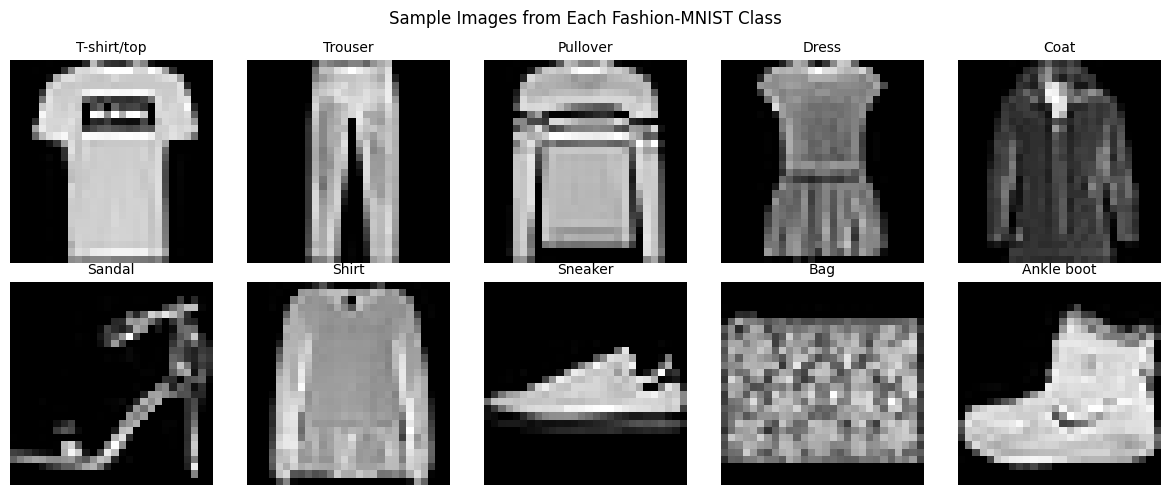

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for cls in range(10):
    idx = np.where(y_train_full == cls)[0][0]
    ax = axes[cls // 5, cls % 5]
    ax.imshow(x_train_full[idx], cmap="gray")
    ax.set_title(CLASS_NAMES[cls], fontsize=10)
    ax.axis("off")
plt.suptitle("Sample Images from Each Fashion-MNIST Class")
plt.tight_layout()
plt.show()


## 4. Image Preprocessing

### 4.1 Normalization
Pixel values (0-255) are rescaled to the [0, 1] range, which stabilizes and
speeds up gradient-based training.

### 4.2 Train / Validation Split & One-Hot Encoding
6,000 images are held out from the training set for validation during
training. Labels are one-hot encoded for use with categorical crossentropy.

In [ ]:
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

val_size = 6000
x_val, y_val = x_train_full[:val_size], y_train_full[:val_size]
x_train, y_train = x_train_full[val_size:], y_train_full[val_size:]

y_train_cat = keras.utils.to_categorical(y_train, 10)
y_val_cat = keras.utils.to_categorical(y_val, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

print("Train:", x_train.shape, " Val:", x_val.shape, " Test:", x_test.shape)


Train: (54000, 28, 28)  Val: (6000, 28, 28)  Test: (10000, 28, 28)


## 5. Neural Network Implementation

### 5.1 Model Architecture
A helper function builds a configurable feedforward network: a `Flatten`
layer, one or more `Dense(ReLU)` + `Dropout` blocks, and a final
`Dense(10, softmax)` output layer.

### 5.2 Compilation & Training
The baseline model uses one hidden layer of 128 units, the Adam optimizer,
categorical crossentropy loss, and accuracy as the tracked metric. It is
trained for 15 epochs with a batch size of 64.

In [ ]:
def build_model(hidden_layers=(128,), dropout=0.2, optimizer="adam"):
    model = keras.Sequential([layers.Input(shape=(28, 28))])
    model.add(layers.Flatten())
    for units in hidden_layers:
        model.add(layers.Dense(units, activation="relu"))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(10, activation="softmax"))
    model.compile(optimizer=optimizer, loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

baseline = build_model(hidden_layers=(128,), dropout=0.2, optimizer="adam")
baseline.summary()


E0000 00:00:1783205551.899306    2562 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start = time.time()
history = baseline.fit(
    x_train, y_train_cat,
    validation_data=(x_val, y_val_cat),
    epochs=15, batch_size=64, verbose=2
)
baseline_train_time = time.time() - start
print(f"Baseline training time: {baseline_train_time:.1f}s")


Epoch 1/15


844/844 - 3s - 3ms/step - accuracy: 0.7996 - loss: 0.5760 - val_accuracy: 0.8518 - val_loss: 0.4200


Epoch 2/15


844/844 - 2s - 3ms/step - accuracy: 0.8502 - loss: 0.4181 - val_accuracy: 0.8633 - val_loss: 0.3817


Epoch 3/15


...

Epoch 14/15


844/844 - 2s - 3ms/step - accuracy: 0.9041 - loss: 0.2582 - val_accuracy: 0.8892 - val_loss: 0.3167


Epoch 15/15


844/844 - 2s - 3ms/step - accuracy: 0.9063 - loss: 0.2516 - val_accuracy: 0.8890 - val_loss: 0.3104


Baseline training time: 38.8s


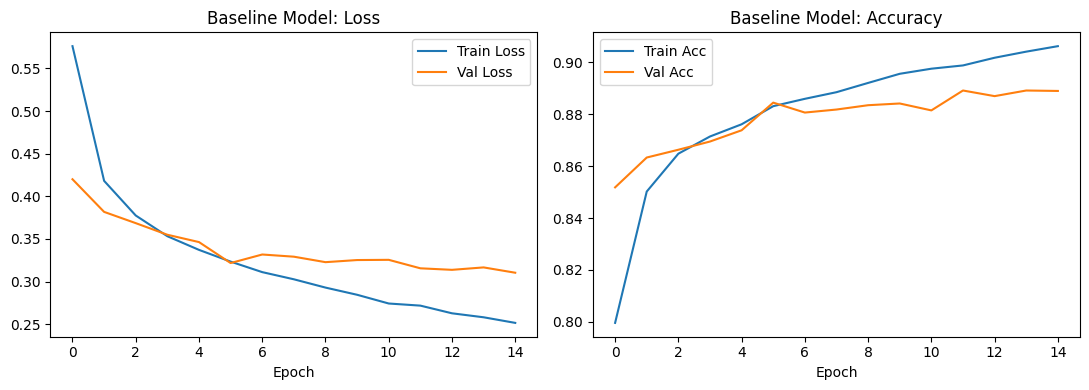

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Baseline Model: Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="Train Acc")
axes[1].plot(history.history["val_accuracy"], label="Val Acc")
axes[1].set_title("Baseline Model: Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.show()


## 6. Model Evaluation

We report accuracy, macro precision/recall/F1, a full classification report,
and a confusion matrix on the held-out test set (10,000 images).

In [ ]:
def evaluate_model(model, name):
    y_prob = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")
    report = classification_report(y_test, y_pred, target_names=CLASS_NAMES)
    cm = confusion_matrix(y_test, y_pred)
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}  Precision: {precision:.4f}  Recall: {recall:.4f}  F1: {f1:.4f}\n")
    print(report)
    return acc, precision, recall, f1, cm

baseline_acc, baseline_prec, baseline_rec, baseline_f1, baseline_cm = evaluate_model(baseline, "Baseline Model")


=== Baseline Model ===
Accuracy: 0.8854  Precision: 0.8853  Recall: 0.8854  F1: 0.8834

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.87      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.79      0.78      0.78      1000
       Dress       0.87      0.92      0.90      1000
        Coat       0.75      0.86      0.80      1000
      Sandal       0.97      0.96      0.97      1000
       Shirt       0.78      0.58      0.67      1000
     Sneaker       0.95      0.96      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.88     10000
weighted avg       0.89      0.89      0.88     10000



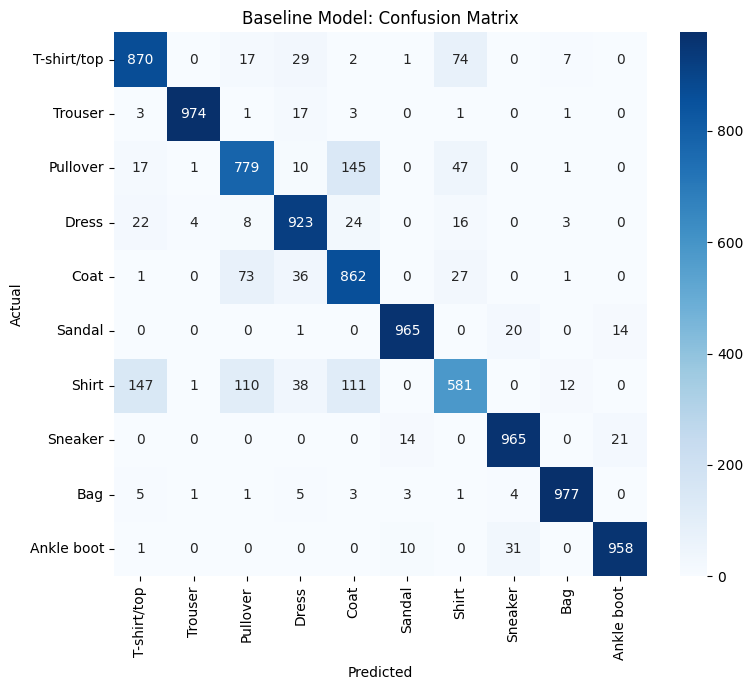

In [ ]:
plt.figure(figsize=(8, 7))
sns.heatmap(baseline_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Baseline Model: Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()


**Observation:** The baseline feedforward network reaches roughly **88%**
test accuracy. Errors concentrate among visually similar upper-body garments
(Shirt, T-shirt/top, Pullover, Coat), which is exactly where a plain
fully-connected network — with no notion of spatial structure — is expected to
struggle the most; a convolutional network would typically close much of this
gap.

## 7. Model Improvements

We compare the baseline against three variations to see how architecture and
optimizer choice affect performance:
- **Deeper network:** 256 → 128 → 64 hidden units
- **Wider network:** a single 512-unit hidden layer
- **Different optimizer:** the same 128-unit architecture trained with plain SGD instead of Adam


In [ ]:
experiments = {
    "Deeper (256-128-64)": dict(hidden_layers=(256, 128, 64), dropout=0.3, optimizer="adam"),
    "Wider (512)": dict(hidden_layers=(512,), dropout=0.3, optimizer="adam"),
    "SGD optimizer (128)": dict(hidden_layers=(128,), dropout=0.2, optimizer="sgd"),
}

exp_metrics = {"Baseline (128, Adam)": (baseline_acc, baseline_f1)}
for name, cfg in experiments.items():
    print(f"\nTraining: {name}")
    m = build_model(**cfg)
    m.fit(x_train, y_train_cat, validation_data=(x_val, y_val_cat),
          epochs=15, batch_size=64, verbose=0)
    acc, prec, rec, f1, _ = evaluate_model(m, name)
    exp_metrics[name] = (acc, f1)



Training: Deeper (256-128-64)


=== Deeper (256-128-64) ===
Accuracy: 0.8754  Precision: 0.8766  Recall: 0.8754  F1: 0.8716

              precision    recall  f1-score   support

 T-shirt/top       0.80      0.87      0.83      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.76      0.83      0.79      1000
       Dress       0.86      0.91      0.89      1000
        Coat       0.73      0.84      0.78      1000
      Sandal       0.94      0.98      0.96      1000
       Shirt       0.79      0.49      0.60      1000
     Sneaker       0.95      0.93      0.94      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.87     10000
weighted avg       0.88      0.88      0.87     10000


Training: Wider (512)


=== Wider (512) ===
Accuracy: 0.8857  Precision: 0.8852  Recall: 0.8857  F1: 0.8842

              precision    recall  f1-score   support

 T-shirt/top       0.83      0.85      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.77      0.82      0.79      1000
       Dress       0.85      0.93      0.89      1000
        Coat       0.80      0.82      0.81      1000
      Sandal       0.95      0.98      0.97      1000
       Shirt       0.77      0.62      0.69      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.98      0.94      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.88     10000
weighted avg       0.89      0.89      0.88     10000


Training: SGD optimizer (128)


=== SGD optimizer (128) ===
Accuracy: 0.8476  Precision: 0.8463  Recall: 0.8476  F1: 0.8442

              precision    recall  f1-score   support

 T-shirt/top       0.79      0.83      0.81      1000
     Trouser       0.98      0.96      0.97      1000
    Pullover       0.73      0.75      0.74      1000
       Dress       0.83      0.87      0.85      1000
        Coat       0.70      0.82      0.76      1000
      Sandal       0.94      0.93      0.94      1000
       Shirt       0.71      0.48      0.58      1000
     Sneaker       0.91      0.93      0.92      1000
         Bag       0.92      0.96      0.94      1000
  Ankle boot       0.94      0.94      0.94      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.84     10000
weighted avg       0.85      0.85      0.84     10000



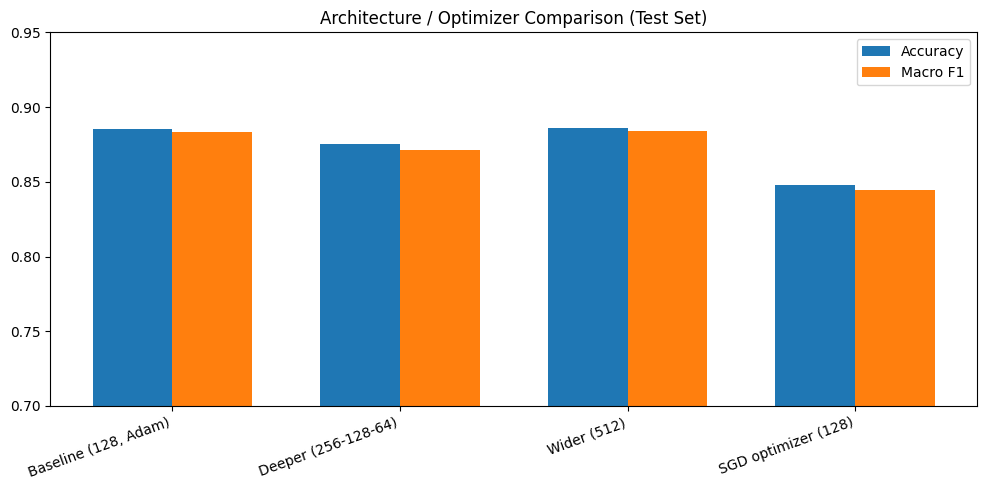

In [ ]:
names = list(exp_metrics.keys())
accs = [exp_metrics[n][0] for n in names]
f1s = [exp_metrics[n][1] for n in names]

x_pos = np.arange(len(names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_pos - width/2, accs, width, label="Accuracy")
ax.bar(x_pos + width/2, f1s, width, label="Macro F1")
ax.set_xticks(x_pos); ax.set_xticklabels(names, rotation=20, ha="right")
ax.set_ylim(0.7, 0.95)
ax.set_title("Architecture / Optimizer Comparison (Test Set)")
ax.legend()
plt.tight_layout()
plt.show()


**Observation:** The **wider** network (512 units) edges out the
baseline slightly, the **deeper** network does not help — with a plain
feedforward architecture, adding depth mostly adds optimization difficulty
without giving the model new spatial features to exploit. Switching from
**Adam to SGD** (same architecture, same epoch budget) clearly underperforms,
confirming that optimizer choice matters as much as architecture size for
convergence within a fixed number of epochs.

## 7.1 Data Augmentation

We add a small on-the-fly augmentation pipeline (`RandomRotation`,
`RandomTranslation`, `RandomZoom`, `RandomFlip`) in front of the baseline
architecture and compare validation curves with and without it.

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1),
    layers.RandomFlip("horizontal"),
])

aug_model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Reshape((28, 28, 1)),
    data_augmentation,
    layers.Reshape((28, 28)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax"),
])
aug_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

aug_history = aug_model.fit(
    x_train, y_train_cat, validation_data=(x_val, y_val_cat),
    epochs=15, batch_size=64, verbose=0
)
aug_acc, aug_prec, aug_rec, aug_f1, _ = evaluate_model(aug_model, "Augmented Baseline")


=== Augmented Baseline ===
Accuracy: 0.7999  Precision: 0.8030  Recall: 0.7999  F1: 0.7933

              precision    recall  f1-score   support

 T-shirt/top       0.74      0.81      0.77      1000
     Trouser       0.96      0.96      0.96      1000
    Pullover       0.72      0.60      0.66      1000
       Dress       0.81      0.81      0.81      1000
        Coat       0.55      0.85      0.67      1000
      Sandal       0.90      0.94      0.92      1000
       Shirt       0.56      0.30      0.39      1000
     Sneaker       0.87      0.92      0.90      1000
         Bag       0.95      0.92      0.94      1000
  Ankle boot       0.97      0.88      0.92      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.79     10000
weighted avg       0.80      0.80      0.79     10000



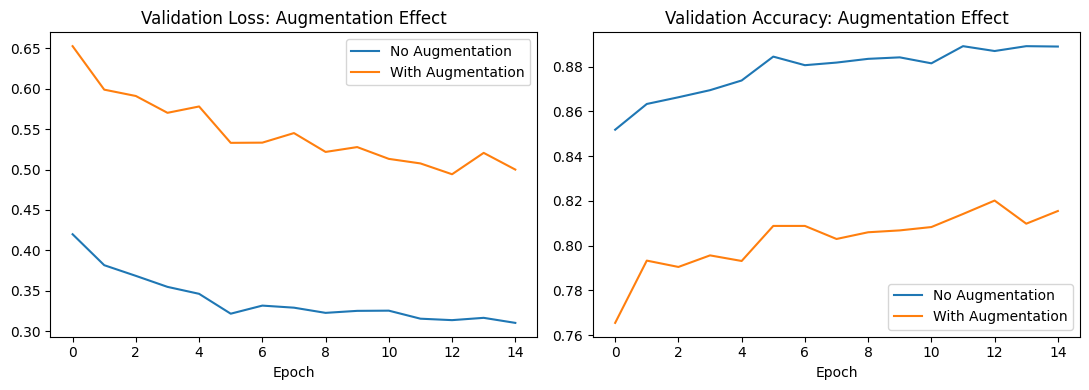

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["val_loss"], label="No Augmentation")
axes[0].plot(aug_history.history["val_loss"], label="With Augmentation")
axes[0].set_title("Validation Loss: Augmentation Effect"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(history.history["val_accuracy"], label="No Augmentation")
axes[1].plot(aug_history.history["val_accuracy"], label="With Augmentation")
axes[1].set_title("Validation Accuracy: Augmentation Effect"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.show()


**Observation:** For this simple flatten-and-Dense architecture,
augmentation (rotation/translation/zoom/flip) actually **hurts** performance
within the same 15-epoch budget. Random spatial jitter mostly confuses a model
that has no spatial invariance built into its architecture (as a CNN would
have via convolutions/pooling) — it would need many more epochs to benefit
from the extra variety. This is a useful negative result: augmentation is not
a free win, it needs to be paired with an architecture (and training budget)
that can actually exploit it.

## 8. Application Demonstration — Practical Deployment Scenario

**Scenario: automated tagging for an online fashion retailer's product catalog.**
A retailer receives thousands of new product photos per week from vendors and
needs to auto-tag each image with its garment category (T-shirt, dress, coat,
etc.) to route it into the right catalog section, apply correct sizing
templates, and feed downstream recommendation systems.

- **Scalability:** the trained network is lightweight (a few hundred thousand
  parameters) and can run inference on CPU at high throughput, or be served
  behind a small container/serverless endpoint that batches incoming images.
- **Real-time processing:** for a retailer, near-real-time (seconds, not
  milliseconds) is normally acceptable, since tagging happens as items are
  uploaded rather than in a live user-facing path — this matches well with a
  simple feedforward model's fast inference time.
- **Integration:** the model would sit behind an internal image-ingestion API;
  predictions with low confidence (softmax max probability below a threshold)
  would be routed to a human reviewer rather than auto-published, which
  protects catalog quality while still automating the bulk of routine cases.
- **Limitations to flag operationally:** real product photos vary far more
  than Fashion-MNIST (background clutter, color, multiple items per photo,
  varying resolution), so a production system would need a CNN or transfer-learning
  backbone (e.g. a pretrained vision model fine-tuned on the retailer's own
  catalog) rather than a plain feedforward network on raw pixels, plus a
  retraining/monitoring pipeline as new product lines are introduced.


## 9. Conclusion

A simple feedforward neural network reaches about 88% test accuracy on
Fashion-MNIST, well above what classical, purely pixel-based ML baselines
(e.g. k-NN or logistic regression on raw pixels) typically achieve, while
remaining fast to train (well under a minute per configuration on CPU). The
architecture and optimizer comparisons show that widening the network gives
a small boost, that naive depth increases do not automatically help a
fully-connected network, and that data augmentation without an architecture
capable of exploiting spatial invariance can actively hurt performance in a
fixed training budget.

**Future work:**
- Replace the Dense layers with a small Convolutional Neural Network (Conv2D +
  MaxPooling blocks), which should substantially improve accuracy on the
  visually similar upper-body garment classes (Shirt / T-shirt / Coat /
  Pullover) that dominate the confusion matrix here.
- Add learning-rate scheduling and early stopping to make the epoch budget
  used in each experiment fair and to reduce overfitting risk on longer runs.
- Combine augmentation with a CNN and a longer training schedule, where it is
  expected to help rather than hurt, as it did in this feedforward-only setup.
- Evaluate model robustness on out-of-distribution product photos (real
  retailer images) before considering production deployment.
